# FraudGuard — 06: Isolation Forest

Denetimsiz (unsupervised) anomali tespit modeli. Etiket (y_train) kullanılmadan sadece X_train üzerinde eğitilir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import joblib
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
METRICS_DIR   = Path('../results/metrics')
FIGURES_DIR   = Path('../results/figures')

In [2]:
with open('../config/model_params.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

IF_CFG = cfg['isolation_forest']
print('Isolation Forest config:', IF_CFG)

Isolation Forest config: {'n_estimators': 100, 'contamination': 0.00173, 'random_state': 42, 'max_samples': 'auto'}


## 1. Veriyi Yükle

In [3]:
X_train = pd.read_csv(PROCESSED_DIR / 'X_train_scaled.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test_scaled.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

fraud_rate_train = y_train.mean()
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Train fraud oranı : {fraud_rate_train:.5f}  (config contamination: {IF_CFG["contamination"]})')
print(f'Test  fraud sayısı: {y_test.sum()}')

X_train: (227845, 30)  |  X_test: (56962, 30)
Train fraud oranı : 0.00173  (config contamination: 0.00173)
Test  fraud sayısı: 98


## 2. Model Eğitimi (Sadece X_train — Etiket Yok)

In [4]:
model = IsolationForest(**IF_CFG)

# Unsupervised: y_train passed to fit
model.fit(X_train)
print('Model eğitildi (etiket kullanılmadı).')
print(f'Ağaç sayısı   : {model.n_estimators}')
print(f'contamination : {model.contamination}')

Model eğitildi (etiket kullanılmadı).
Ağaç sayısı   : 100
contamination : 0.00173


## 3. Tahmin ve Skor Dönüşümü

In [5]:
# predict() returns: -1 = anomaly (fraud), 1 = normal
raw_pred      = model.predict(X_test)
y_pred        = (raw_pred == -1).astype(int)   # -1 → 1 (fraud), 1 → 0 (normal)
anomaly_score = -model.score_samples(X_test)   # negate: higher = more anomalous

print('Tahmin tamamlandı.')
print(f'Tahmin edilen fraud sayısı: {y_pred.sum()}')
print(f'Gerçek fraud sayısı:        {y_test.sum()}')

Tahmin tamamlandı.
Tahmin edilen fraud sayısı: 107
Gerçek fraud sayısı:        98


## 4. Metrikler

In [6]:
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, anomaly_score)
pr_auc    = average_precision_score(y_test, anomaly_score)

print('=== Isolation Forest — Test Seti Metrikleri ===')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1        : {f1:.4f}')
print(f'ROC-AUC   : {roc_auc:.4f}')
print(f'PR-AUC    : {pr_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

=== Isolation Forest — Test Seti Metrikleri ===
Precision : 0.3084
Recall    : 0.3367
F1        : 0.3220
ROC-AUC   : 0.9543
PR-AUC    : 0.2180

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.31      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



In [7]:
with open(METRICS_DIR / '05_baseline_metrics.json', 'r') as f:
    lr_metrics = json.load(f)
with open(METRICS_DIR / '06_random_forest_metrics.json', 'r') as f:
    rf_metrics = json.load(f)
with open(METRICS_DIR / '07_xgboost_metrics.json', 'r') as f:
    xgb_metrics = json.load(f)

comparison = pd.DataFrame([
    {'Model': 'Logistic Regression (baseline)',
     'Precision': lr_metrics['precision'],  'Recall': lr_metrics['recall'],
     'F1': lr_metrics['f1'], 'ROC-AUC': lr_metrics['roc_auc'], 'PR-AUC': lr_metrics['pr_auc']},
    {'Model': 'Random Forest (balanced)',
     'Precision': rf_metrics['precision'],  'Recall': rf_metrics['recall'],
     'F1': rf_metrics['f1'], 'ROC-AUC': rf_metrics['roc_auc'], 'PR-AUC': rf_metrics['pr_auc']},
    {'Model': 'XGBoost (scale_pos_weight=577)',
     'Precision': xgb_metrics['precision'], 'Recall': xgb_metrics['recall'],
     'F1': xgb_metrics['f1'], 'ROC-AUC': xgb_metrics['roc_auc'], 'PR-AUC': xgb_metrics['pr_auc']},
    {'Model': 'Isolation Forest (unsupervised)',
     'Precision': round(float(precision), 4), 'Recall': round(float(recall), 4),
     'F1': round(float(f1), 4), 'ROC-AUC': round(float(roc_auc), 4), 'PR-AUC': round(float(pr_auc), 4)},
]).set_index('Model')

print('=== 4 Model Karşılaştırması ===')
print(comparison.to_string())

=== 4 Model Karşılaştırması ===


                                 Precision  Recall      F1  ROC-AUC  PR-AUC
Model                                                                      
Logistic Regression (baseline)      0.8267  0.6327  0.7168   0.9605  0.7414
Random Forest (balanced)            0.9605  0.7449  0.8391   0.9529  0.8539
XGBoost (scale_pos_weight=577)      0.7757  0.8469  0.8098   0.9815  0.8597
Isolation Forest (unsupervised)     0.3084  0.3367  0.3220   0.9543  0.2180


## 5. Confusion Matrix

TN=56,790  FP=74  FN=65  TP=33


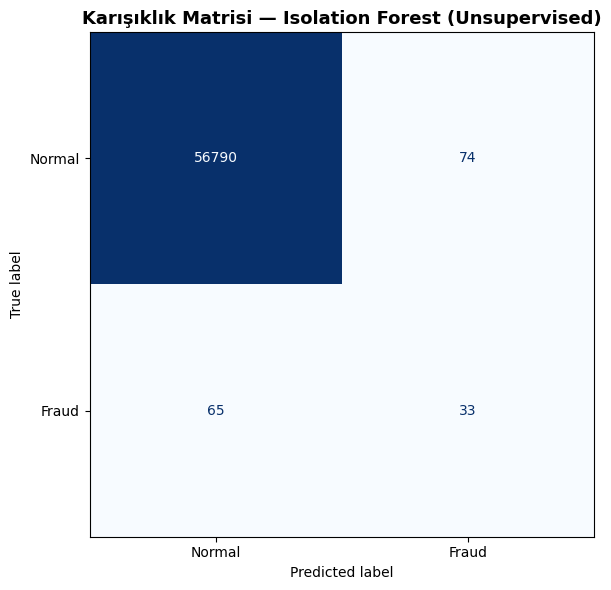

Saved: 15_if_confusion_matrix.png


In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Karışıklık Matrisi — Isolation Forest (Unsupervised)', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '15_if_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 15_if_confusion_matrix.png')

## 6. ROC ve PR Eğrileri

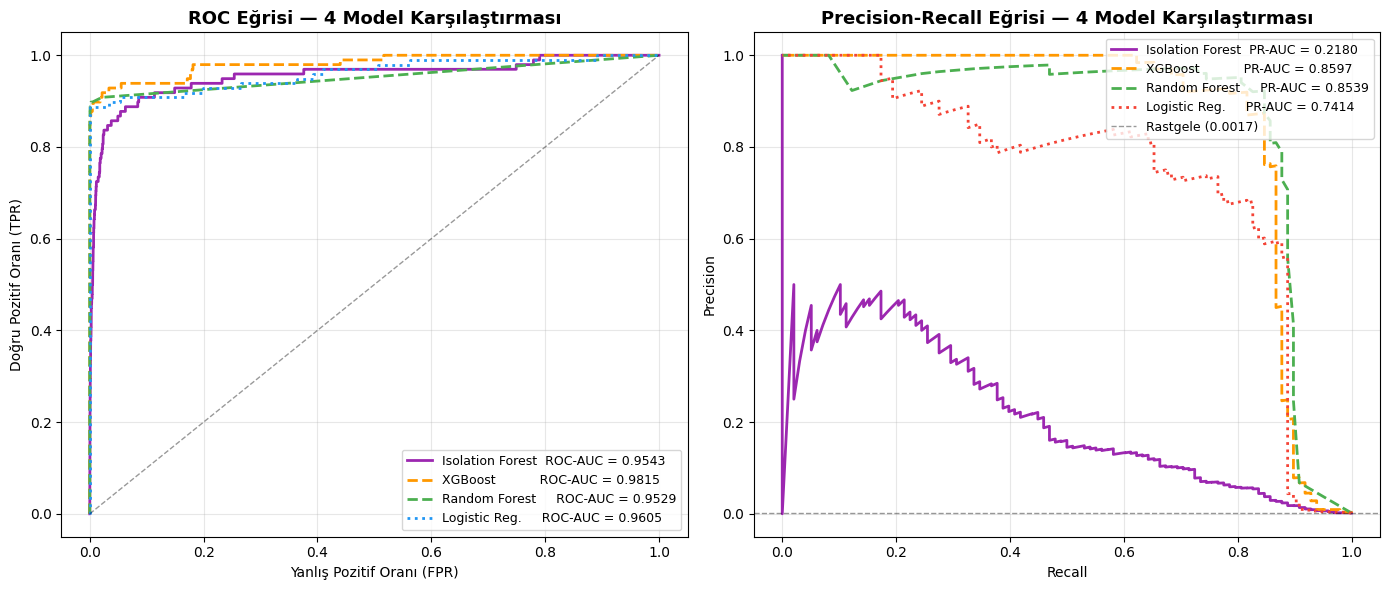

Saved: 16_if_roc_pr_curves.png


In [9]:
lr_model  = joblib.load(MODELS_DIR / 'logistic_regression.pkl')
rf_model  = joblib.load(MODELS_DIR / 'random_forest.pkl')
xgb_model = joblib.load(MODELS_DIR / 'xgboost.pkl')

lr_proba  = lr_model.predict_proba(X_test)[:, 1]
rf_proba  = rf_model.predict_proba(X_test)[:, 1]
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

fpr_if,  tpr_if,  _ = roc_curve(y_test, anomaly_score)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_proba)
fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_proba)

prec_if,  rec_if,  _ = precision_recall_curve(y_test, anomaly_score)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_proba)
prec_rf,  rec_rf,  _ = precision_recall_curve(y_test, rf_proba)
prec_lr,  rec_lr,  _ = precision_recall_curve(y_test, lr_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
axes[0].plot(fpr_if,  tpr_if,  color='#9C27B0', lw=2,
             label=f'Isolation Forest  ROC-AUC = {roc_auc:.4f}')
axes[0].plot(fpr_xgb, tpr_xgb, color='#FF9800', lw=2, linestyle='--',
             label=f'XGBoost           ROC-AUC = {xgb_metrics["roc_auc"]:.4f}')
axes[0].plot(fpr_rf,  tpr_rf,  color='#4CAF50', lw=2, linestyle='--',
             label=f'Random Forest     ROC-AUC = {rf_metrics["roc_auc"]:.4f}')
axes[0].plot(fpr_lr,  tpr_lr,  color='#2196F3', lw=2, linestyle=':',
             label=f'Logistic Reg.     ROC-AUC = {lr_metrics["roc_auc"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
axes[0].set_xlabel('Yanlış Pozitif Oranı (FPR)')
axes[0].set_ylabel('Doğru Pozitif Oranı (TPR)')
axes[0].set_title('ROC Eğrisi — 4 Model Karşılaştırması', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# PR
baseline_rate = y_test.mean()
axes[1].plot(rec_if,  prec_if,  color='#9C27B0', lw=2,
             label=f'Isolation Forest  PR-AUC = {pr_auc:.4f}')
axes[1].plot(rec_xgb, prec_xgb, color='#FF9800', lw=2, linestyle='--',
             label=f'XGBoost           PR-AUC = {xgb_metrics["pr_auc"]:.4f}')
axes[1].plot(rec_rf,  prec_rf,  color='#4CAF50', lw=2, linestyle='--',
             label=f'Random Forest     PR-AUC = {rf_metrics["pr_auc"]:.4f}')
axes[1].plot(rec_lr,  prec_lr,  color='#F44336', lw=2, linestyle=':',
             label=f'Logistic Reg.     PR-AUC = {lr_metrics["pr_auc"]:.4f}')
axes[1].axhline(y=baseline_rate, color='k', linestyle='--', lw=1, alpha=0.4,
                label=f'Rastgele ({baseline_rate:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Eğrisi — 4 Model Karşılaştırması', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '16_if_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 16_if_roc_pr_curves.png')

## 7. Model ve Metrik Kaydet

In [10]:
joblib.dump(model, MODELS_DIR / 'isolation_forest.pkl')
print('Model kaydedildi: models/isolation_forest.pkl')

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

metrics = {
    'model'        : 'IsolationForest',
    'step'         : '08_isolation_forest',
    'supervised'   : False,
    'contamination': IF_CFG['contamination'],
    'n_estimators' : IF_CFG['n_estimators'],
    'precision'    : round(float(precision), 4),
    'recall'       : round(float(recall),    4),
    'f1'           : round(float(f1),        4),
    'roc_auc'      : round(float(roc_auc),   4),
    'pr_auc'       : round(float(pr_auc),    4),
    'confusion_matrix': {
        'TN': int(tn), 'FP': int(fp),
        'FN': int(fn), 'TP': int(tp)
    }
}

with open(METRICS_DIR / '08_isolation_forest_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(json.dumps(metrics, indent=2))
print('\nSaved: 08_isolation_forest_metrics.json')

Model kaydedildi: models/isolation_forest.pkl
{
  "model": "IsolationForest",
  "step": "08_isolation_forest",
  "supervised": false,
  "contamination": 0.00173,
  "n_estimators": 100,
  "precision": 0.3084,
  "recall": 0.3367,
  "f1": 0.322,
  "roc_auc": 0.9543,
  "pr_auc": 0.218,
  "confusion_matrix": {
    "TN": 56790,
    "FP": 74,
    "FN": 65,
    "TP": 33
  }
}

Saved: 08_isolation_forest_metrics.json
